<img src="https://raw.githubusercontent.com/carubbi/MQ/main/notebooks/assets/imgs/unifor-logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

# Aula 7 — Medidas de posição e dispersão em Python

## 1. Objetivos de aprendizagem

Ao final da aula, o aluno será capaz de:

- calcular, interpretar e justificar o uso de medidas de posição e dispersão;
- interpretar quantis como medidas de posição em uma distribuição;
- comparar a sensibilidade e a robustez das medidas diante de valores extremos;
- avaliar a dispersão absoluta e relativa, empregando o coeficiente de variação somente quando sua interpretação for coerente;
- comparar medidas obtidas com dados individuais e aproximações baseadas em classes, reconhecendo a perda de informação;
- sintetizar criticamente os resultados estatísticos com apoio de Python e unidades adequadas.

## 2. Agenda

1. Preparação dos dados e funções auxiliares — 10 min
2. Medidas para dados não agrupados — 50 min
3. Medidas para dados agrupados em classes — 20 min
4. Comparação e interpretação dos resultados — 15 min
5. Estudo e exercícios — 5 min

As células de visualização serão apresentadas já executadas e não serão desenvolvidas durante a aula.

## 3. Preparação dos dados e funções auxiliares

### 3.1 Bibliotecas e dados organizados

In [1]:
# Importa as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Carrega o conjunto de dados
url = "https://raw.githubusercontent.com/carubbi/MQ/main/data/processed/penguins.csv"
penguins = pd.read_csv(url)
massa = penguins["body_mass_g"]
massa_observada = massa.dropna()

# Exibe informações sobre o conjunto de dados
print("Dimensão do conjunto:", penguins.shape)
print("Massas observadas:", massa_observada.count())

Dimensão do conjunto: (344, 8)
Massas observadas: 342


### 3.2 Preparação comum das ausências com biblioteca

Esta etapa não faz parte da implementação manual das medidas. A função auxiliar
recebe uma `pandas.Series`; ela não converte listas. O método `Series.dropna()`
remove somente os valores ausentes, como `None` e `NaN`, sem substituí-los por
zero e sem alterar a série recebida (MCKINNEY, 2017, pp. 209–213). Nesta aula,
$n$ representa o número de observações válidas da variável após essa remoção.

Quando os valores estiverem inicialmente em uma lista, faça a conversão antes:

In [2]:
# Converte uma lista de exemplo em Series, preservando os valores ausentes.
valores = pd.Series([1, 2, None, 4], dtype=float)

In [3]:
# Define a preparação comum que remove ausências e verifica o tamanho mínimo.
def _validos(valores: pd.Series, minimo: int = 1) -> pd.Series:
    """Remove ausências de uma série sem convertê-la."""
    if not isinstance(valores, pd.Series):
        raise TypeError(
            "valores deve ser pandas.Series numérica ou booleana; "
            "converta listas antes com pd.Series(valores)."
        )
    serie = valores.dropna()
    if len(serie) < minimo:
        raise ValueError(
            f"São necessárias pelo menos {minimo} observações válidas."
        )
    return serie

## 4. Medidas para dados não agrupados

### 4.1 Média amostral

#### Fundamentação

A média aritmética resume a posição dos dados usando a magnitude de todas as
observações e pode ser interpretada como seu ponto de equilíbrio. Por utilizar
todos os valores, é sensível a observações extremas (MORETTIN; BUSSAB, 2010,
pp. 52–54; BARBETTA; REIS; BORNIA, 2010, pp. 69–71):

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i.
\tag{7.1}
$$

Onde:

- $x_i$: $i$-ésima observação válida;
- $n$: tamanho amostral válido.

A média $\bar{x}$ mantém a unidade original da variável.

#### Implementação manual

In [4]:
# Implementa a média diretamente pela definição.
def media(valores: pd.Series) -> float:
    """Calcula a média pela soma dos valores observados."""
    observados = _validos(valores)
    return sum(observados) / len(observados)

#### Implementação com biblioteca

In [5]:
# Implementa a média com pandas.
def media_pd(valores: pd.Series) -> float:
    """Calcula a média com pandas.Series.mean."""
    serie = _validos(valores)
    return float(serie.mean())

#### Aplicação

Cálculo manual:

$$
\bar{x}=\frac{1437000}{342}\approx4201{,}75\ \mathrm{g}.
$$

In [6]:
# Calcula a média pelas duas implementações
media_m = media(massa)
media_b = media_pd(massa)

# Exibe e compara os resultados
print("Manual:", media_m)
print("pandas:", media_b)
print("Diferença:", media_m - media_b)

Manual: 4201.754385964912
pandas: 4201.754385964912
Diferença: 0.0


#### Visualização

Um valor artificial extremo desloca a média da pequena amostra de pinguins
Adelie.

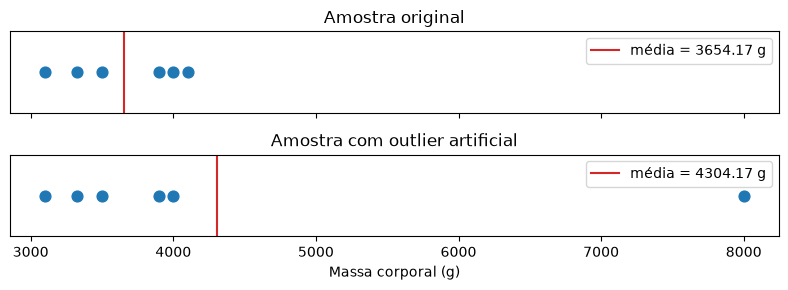

In [7]:
# Seleciona uma pequena amostra de pinguins Adelie
massa_adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "body_mass_g",
].dropna()

# Cria a amostra original e a versão com outlier
amostra_adelie = (
    massa_adelie.sample(6, random_state=7)
    .sort_values()
    .reset_index(drop=True)
)
amostra_outlier = amostra_adelie.copy()
amostra_outlier.iloc[-1] = 8000  # valor artificial

# Compara graficamente as médias das duas amostras
fig, eixos = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
for eixo, dados, titulo in zip(
    eixos,
    [amostra_adelie, amostra_outlier],
    ["Amostra original", "Amostra com outlier artificial"],
):
    eixo.scatter(dados, np.zeros(len(dados)), s=60)
    eixo.axvline(
        dados.mean(),
        color="tab:red",
        label=f"média = {dados.mean():.2f} g",
    )
    eixo.set_yticks([])
    eixo.set_title(titulo)
    eixo.legend()

eixos[-1].set_xlabel("Massa corporal (g)")
plt.tight_layout()
plt.show()

### 4.2 Mediana

#### Fundamentação

A mediana ocupa o centro da amostra ordenada: quando $n$ é ímpar, corresponde
à observação central; quando $n$ é par, é a média das duas observações centrais
(MORETTIN; BUSSAB, 2010, pp. 52–54; PINHEIRO et al., 2009, pp. 35–36):

$$
\widetilde{x}=
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & n\ \text{ímpar},\\[6pt]
\dfrac{x_{\left(\frac{n}{2}\right)}+
x_{\left(\frac{n}{2}+1\right)}}{2}, & n\ \text{par}.
\end{cases}
\tag{7.2}
$$

Onde:

- $x_{(r)}$: estatística de ordem na posição $r$;
- $\widetilde{x}$: mediana amostral.

A mediana separa os dados ordenados em duas metades e é mais robusta a
valores extremos que a média (PINHEIRO et al., 2009, pp. 41–42).

#### Implementação manual

In [8]:
# Implementa a mediana diretamente a partir dos dados ordenados.
def mediana(valores: pd.Series) -> float:
    """Calcula a mediana depois de ordenar uma cópia dos valores."""
    ordenados = sorted(_validos(valores))
    n = len(ordenados)
    meio = n // 2
    if n % 2 == 1:
        return ordenados[meio]
    return (ordenados[meio - 1] + ordenados[meio]) / 2

#### Implementação com biblioteca

In [9]:
# Implementa a mediana com pandas.
def mediana_pd(valores: pd.Series) -> float:
    """Calcula a mediana com pandas.Series.median."""
    serie = _validos(valores)
    return float(serie.median())

#### Aplicação

Cálculo manual:

$$
\widetilde{x}
=\frac{x_{(171)}+x_{(172)}}{2}
=\frac{4050+4050}{2}
=4050\ \mathrm{g}.
$$

In [10]:
# Compara a mediana manual com o resultado do pandas.
print("Manual:", mediana(massa))
print("pandas:", mediana_pd(massa))

Manual: 4050.0
pandas: 4050.0


#### Visualização

A mediana da pequena amostra de pinguins Adelie permanece igual após a
contaminação artificial.

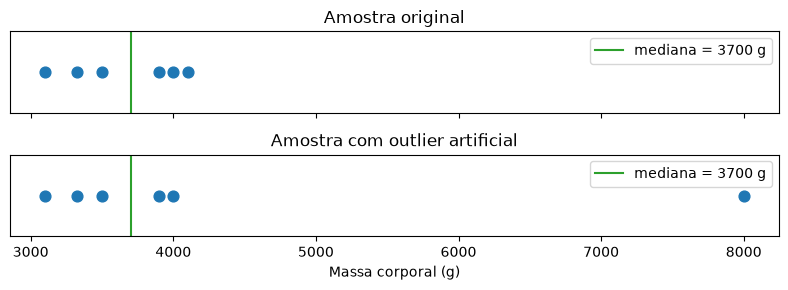

In [11]:
# Mostra a robustez da mediana ao mesmo valor extremo.
fig, eixos = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
for eixo, dados, titulo in zip(
    eixos,
    [amostra_adelie, amostra_outlier],
    ["Amostra original", "Amostra com outlier artificial"],
):
    eixo.scatter(dados, np.zeros(len(dados)), s=60)
    eixo.axvline(
        dados.median(),
        color="tab:green",
        label=f"mediana = {dados.median():.0f} g",
    )
    eixo.set_yticks([])
    eixo.set_title(titulo)
    eixo.legend()

eixos[-1].set_xlabel("Massa corporal (g)")
plt.tight_layout()
plt.show()

### 4.3 Moda

#### Fundamentação

A moda é definida pela frequência das realizações observadas, e uma distribuição
pode apresentar uma ou mais modas (MORETTIN; BUSSAB, 2010, pp. 52–54;
PINHEIRO et al., 2009, pp. 35–36). Para um valor observado $v$, defina sua
frequência absoluta por:

$$
\nu(v)=\sum_{i=1}^{n}\mathbb{1}(x_i=v).
\tag{7.3}
$$

Onde:

- $\mathbb{1}(x_i=v)$: vale 1 quando $x_i=v$ e 0 caso contrário.

O conjunto das modas contém todos os valores com frequência máxima:

$$
\operatorname{Mo}(x)=
\left\{v:\nu(v)=\max_{u}\nu(u)\right\}.
\tag{7.4}
$$

Onde:

- $\nu(v)$: frequência do valor $v$;
- $u$: valor observado considerado na maximização;
- $\operatorname{Mo}(x)$: conjunto das modas.

A definição preserva amostras multimodais. Se todos os valores aparecem uma
vez, todos empatam matematicamente, embora não haja moda substantivamente
informativa.

#### Implementação manual

In [12]:
# Identifica manualmente todos os valores de frequência máxima.
def modas(valores: pd.Series) -> list[int | float | bool]:
    """Retorna, em ordem crescente, todos os valores de frequência máxima."""
    freq = _validos(valores).value_counts()
    modais = freq[freq == freq.max()].index
    return sorted(modais)

#### Implementação com biblioteca

Series.mode é preferido a scipy.stats.mode porque preserva todas as modas.

In [13]:
# Obtém todas as modas com pandas.
def modas_pd(valores: pd.Series) -> list[int | float | bool]:
    """Retorna todas as modas com pandas.Series.mode."""
    serie = _validos(valores)
    return serie.mode().tolist()

#### Aplicação

Cálculo manual:

$$
\nu(3800)=12=\max_v\nu(v)
\quad\Longrightarrow\quad
\operatorname{Mo}(x)=\{3800\}\ \mathrm{g}.
$$

In [14]:
# Compara as modas obtidas pelas duas implementações.
print("Manual:", modas(massa))
print("pandas:", modas_pd(massa))

Manual: [3800.0]
pandas: [3800.0]


#### Visualização

A barra mais alta identifica a moda.

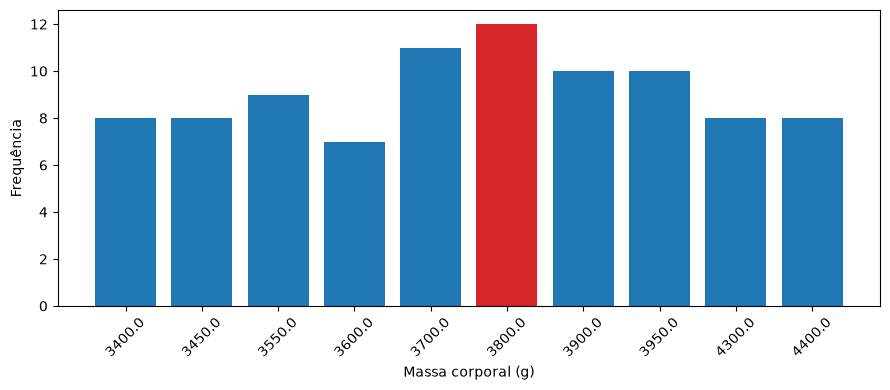

In [15]:
# Calcula as maiores frequências observadas
freq_massa = massa_observada.value_counts().nlargest(10).sort_index()

# Define a cor que destaca a moda
cores = [
    "tab:red" if frequencia == freq_massa.max() else "tab:blue"
    for frequencia in freq_massa
]

# Constrói o gráfico das frequências
fig, eixo = plt.subplots(figsize=(9, 4))
eixo.bar(freq_massa.index.astype(str), freq_massa, color=cores)
eixo.set_xlabel("Massa corporal (g)")
eixo.set_ylabel("Frequência")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Quantis

#### Fundamentação

O quantil de ordem $p$ divide a amostra ordenada de modo que uma proporção
aproximada $p$ das observações fique até esse ponto. Quartis, decis e percentis
são *medidas separatrizes* obtidas ao dividir os dados, respectivamente, em
$m=4$, $m=10$ e $m=100$ partes (MORETTIN; BUSSAB, 2010, pp. 58–63;
BARBETTA; REIS; BORNIA, 2010, pp. 79–81).

Para uma posição $h$, sejam $i=\lfloor h\rfloor$ sua parte inteira e $d=h-i$
sua parte decimal. A função de interpolação $I(h)$ é:

$$
I(h)=
\begin{cases}
x_{(1)}, & h\leq1,\\[3pt]
(1-d)x_{(i)}+d x_{(i+1)}, & 1<h<n,\\[3pt]
x_{(n)}, & h\geq n.
\end{cases}
$$

Para a $j$-ésima separatriz entre $m$ partes:

$$
p=\frac{j}{m}.
\tag{7.5}
$$

Seja $H_p$ a posição teórica do quantil $q_p$ na amostra ordenada:

$$
\begin{gathered}
H_p=1+(n-1)p,\qquad q_p=I(H_p).
\end{gathered}
\tag{7.6}
$$

#### Implementação manual

In [16]:
# Define a interpolação de uma posição teórica
def _interpolar_posicao(ordenados: list[float], h: float) -> float:
    """Interpola uma posição matemática h, indexada a partir de 1."""
    n = len(ordenados)
    if h <= 1:
        return ordenados[0]
    if h >= n:
        return ordenados[-1]

    i = int(h)
    d = h - i
    x_i = ordenados[i - 1]
    x_sup = ordenados[i]
    return x_i + d * (x_sup - x_i)


# Calcula o quantil pela definição
def quantil(valores: pd.Series, p: float) -> float:
    """Calcula q_p por interpolação linear."""
    if not 0 <= p <= 1:
        raise ValueError("p deve pertencer ao intervalo [0, 1].")

    ordenados = sorted(_validos(valores))
    h = 1 + (len(ordenados) - 1) * p
    return _interpolar_posicao(ordenados, h)

#### Implementação com biblioteca

NumPy e pandas oferecem interpolação linear.

In [17]:
# Calcula o quantil linear com NumPy
def quantil_np(valores: pd.Series, p: float) -> float:
    """Calcula q_p pela interpolação linear do NumPy."""
    if not 0 <= p <= 1:
        raise ValueError("p deve pertencer ao intervalo [0, 1].")
    serie = _validos(valores)
    return float(np.quantile(serie, p, method="linear"))


# Calcula o quantil linear com pandas
def quantil_pd(valores: pd.Series, p: float) -> float:
    """Calcula q_p pela convenção linear padrão do pandas."""
    if not 0 <= p <= 1:
        raise ValueError("p deve pertencer ao intervalo [0, 1].")
    serie = _validos(valores)
    return float(serie.quantile(p, interpolation="linear"))

#### Aplicação

Cálculo manual pela interpolação linear:

$$
H_{\frac{3}{4}}=1+(342-1)\frac{3}{4}=1+341\left(\frac{3}{4}\right)
=256{,}75.
$$

$$
i=\lfloor256{,}75\rfloor=256,
\qquad
d=256{,}75-256=0{,}75.
$$

Na amostra ordenada:

$$
x_{(256)}=4750,
\qquad
x_{(257)}=4750.
$$

Aplicando a interpolação:

$$
\begin{aligned}
Q_3&=(1-0{,}75)x_{(256)}+0{,}75x_{(257)}\\
&=0{,}25(4750)+0{,}75(4750)\\
&=4750\ \mathrm{g}.
\end{aligned}
$$

In [18]:
# Compara os três quartis entre as implementações.
for p, nome in [(0.25, "Q1"), (0.50, "Q2"), (0.75, "Q3")]:
    print(
        nome,
        "manual =", quantil(massa, p),
        "NumPy linear =", quantil_np(massa, p),
        "pandas linear =", quantil_pd(massa, p),
    )

Q1 manual = 3550.0 NumPy linear = 3550.0 pandas linear = 3550.0
Q2 manual = 4050.0 NumPy linear = 4050.0 pandas linear = 4050.0
Q3 manual = 4750.0 NumPy linear = 4750.0 pandas linear = 4750.0


#### Visualização

A curva acumulada mostra as posições de $Q_1$, $Q_2$ e $Q_3$.

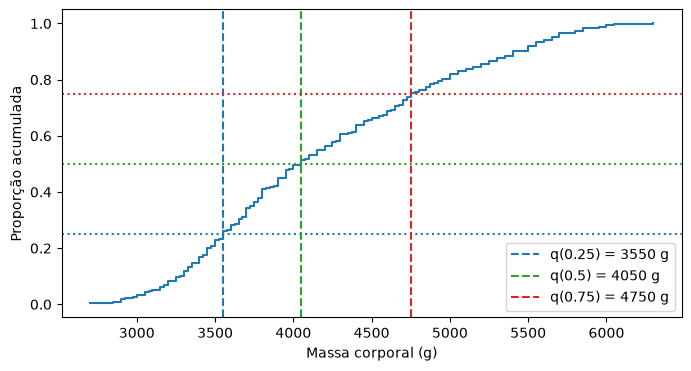

In [19]:
# Ordena as massas e calcula as proporções acumuladas
ordenadas = np.sort(massa_observada.to_numpy())
proporcoes = np.arange(1, len(ordenadas) + 1) / len(ordenadas)

# Constrói a distribuição acumulada e localiza os quartis
fig, eixo = plt.subplots(figsize=(8, 4))
eixo.step(ordenadas, proporcoes, where="post")
for p, cor in [(0.25, "tab:blue"), (0.50, "tab:green"), (0.75, "tab:red")]:
    q = quantil(massa, p)
    eixo.axhline(p, color=cor, linestyle=":")
    eixo.axvline(q, color=cor, linestyle="--", label=f"q({p}) = {q:.0f} g")

eixo.set_xlabel("Massa corporal (g)")
eixo.set_ylabel("Proporção acumulada")
eixo.legend()
plt.show()

### 4.5 Amplitude total

#### Fundamentação

A amplitude total usa somente os extremos da amostra e mede a extensão entre o
menor e o maior valor (BARBETTA; REIS; BORNIA, 2010, pp. 71–72):

$$
R=x_{(n)}-x_{(1)}.
\tag{7.7}
$$

Onde:

- $R$: amplitude total;
- $x_{(1)}$: valor mínimo;
- $x_{(n)}$: valor máximo.

A amplitude mantém a unidade original, mas ignora os valores internos e é
particularmente sensível a extremos.

#### Implementação manual

In [20]:
# Implementa a amplitude pela diferença entre máximo e mínimo.
def amplitude(valores: pd.Series) -> float:
    """Calcula máximo menos mínimo com operações nativas."""
    observados = _validos(valores)
    return float(max(observados) - min(observados))

#### Implementação com biblioteca

Com pandas, basta subtrair o mínimo do máximo.

In [21]:
# Implementa a amplitude com pandas.
def amplitude_pd(valores: pd.Series) -> float:
    """Calcula a amplitude com máximo e mínimo do pandas."""
    serie = _validos(valores)
    return float(serie.max() - serie.min())

#### Aplicação

Cálculo manual:

$$
R=6300-2700=3600\ \mathrm{g}.
$$

In [22]:
# Compara a amplitude entre as duas implementações.
print("Manual:", amplitude(massa))
print("pandas:", amplitude_pd(massa))

Manual: 3600.0
pandas: 3600.0


#### Visualização

O segmento entre o mínimo e o máximo representa a amplitude total.

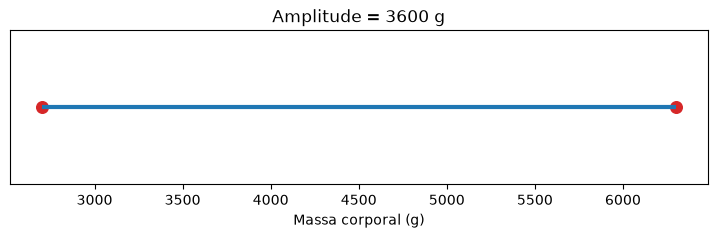

In [23]:
# Obtém os valores mínimo e máximo
minimo = massa_observada.min()
maximo = massa_observada.max()

# Representa graficamente a amplitude total
fig, eixo = plt.subplots(figsize=(9, 2))
eixo.hlines(0, minimo, maximo, color="tab:blue", linewidth=3)
eixo.scatter([minimo, maximo], [0, 0], color="tab:red", s=70)
eixo.set_yticks([])
eixo.set_xlabel("Massa corporal (g)")
eixo.set_title(f"Amplitude = {maximo - minimo:.0f} g")
plt.show()

### 4.6 Variância amostral

#### Fundamentação

A variância amostral resume a dispersão pela soma dos desvios quadráticos em
relação à média. O uso do denominador $n-1$, conhecido como **correção de
Bessel**, corrige a tendência de subestimar a variância populacional quando a
média é calculada com a própria amostra (PINHEIRO et al., 2009, pp. 36–39;
BARBETTA; REIS; BORNIA, 2010, pp. 72–76):

$$
s^2=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2.
\tag{7.8}
$$

Onde:

- $x_i-\bar{x}$: desvio da $i$-ésima observação em relação à média.

A unidade de $s^2$ é o quadrado da unidade original; para massa,
$\mathrm{g}^2$.

#### Implementação manual

In [24]:
# Implementa a variância amostral com denominador n menos 1.
def variancia(valores: pd.Series) -> float:
    """Calcula a variância amostral com denominador n - 1."""
    observados = _validos(valores, minimo=2)
    media_valor = media(observados)
    soma_quadrados = 0.0
    for valor in observados:
        soma_quadrados += (valor - media_valor) ** 2
    return soma_quadrados / (len(observados) - 1)

#### Implementação com biblioteca

Series.var usa $n-\mathrm{ddof}$ no denominador. O argumento ddof=1 torna a
decisão estatística visível.

In [25]:
# Implementa a variância amostral com pandas e ddof igual a 1.
def variancia_pd(valores: pd.Series) -> float:
    """Calcula a variância amostral com pandas e ddof=1."""
    serie = _validos(valores, minimo=2)
    return float(serie.var(ddof=1))

#### Aplicação

Cálculo manual:

$$
s^2
=\frac{219307697{,}37}{342-1}
\approx643131{,}08\ \mathrm{g}^2.
$$

In [26]:
# Compara a variância amostral entre as duas implementações.
print("Manual:", variancia(massa))
print("pandas:", variancia_pd(massa))

Manual: 643131.0773267484
pandas: 643131.0773267479


#### Visualização

Adelie e Chinstrap têm médias próximas, mas dispersões diferentes.

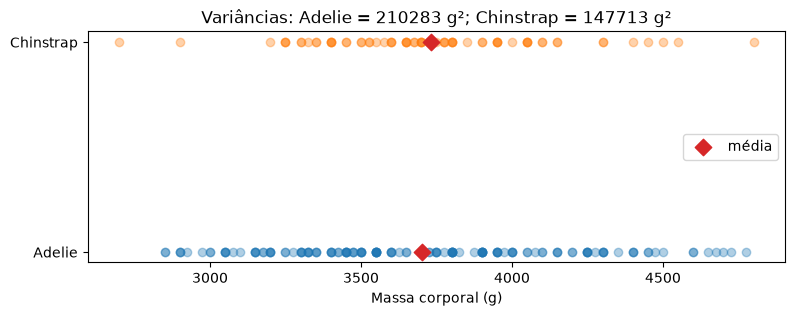

In [27]:
# Seleciona as massas de Adelie e Chinstrap
massas_adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "body_mass_g",
].dropna()
massas_chinstrap = penguins.loc[
    penguins["species"] == "Chinstrap",
    "body_mass_g",
].dropna()

# Compara graficamente a dispersão das espécies
fig, eixo = plt.subplots(figsize=(9, 3))
for posicao, dados, especie in [
    (0, massas_adelie, "Adelie"),
    (1, massas_chinstrap, "Chinstrap"),
]:
    eixo.scatter(dados, np.full(len(dados), posicao), alpha=0.35)
    eixo.scatter(
        dados.mean(),
        posicao,
        marker="D",
        color="tab:red",
        s=70,
        label="média" if posicao == 0 else None,
    )

eixo.set_yticks([0, 1], ["Adelie", "Chinstrap"])
eixo.set_xlabel("Massa corporal (g)")
eixo.set_title(
    f"Variâncias: Adelie = {massas_adelie.var(ddof=1):.0f} g²; "
    f"Chinstrap = {massas_chinstrap.var(ddof=1):.0f} g²"
)
eixo.legend()
plt.show()

### 4.7 Desvio-padrão amostral

#### Fundamentação

O desvio-padrão amostral é a raiz quadrada positiva da variância amostral
(MORETTIN; BUSSAB, 2010, pp. 55–57; PINHEIRO et al., 2009, pp. 36–39):

$$
s=\sqrt{s^2}.
\tag{7.9}
$$

Como $s\geq0$, a medida retorna à unidade original dos dados e pode ser lida
como uma escala típica dos desvios em torno da média.

#### Implementação manual

In [28]:
# Implementa o desvio-padrão como raiz da variância amostral.
def desvio(valores: pd.Series) -> float:
    """Calcula a raiz da variância amostral sem importar math."""
    return variancia(valores) ** 0.5

#### Implementação com biblioteca

In [29]:
# Implementa o desvio-padrão amostral com pandas.
def desvio_pd(valores: pd.Series) -> float:
    """Calcula o desvio-padrão com pandas e ddof=1."""
    serie = _validos(valores, minimo=2)
    return float(serie.std(ddof=1))

#### Aplicação

Cálculo manual:

$$
s=\sqrt{643131{,}08}\approx801{,}95\ \mathrm{g}.
$$

In [30]:
# Compara o desvio-padrão entre as duas implementações.
print("Manual:", desvio(massa))
print("pandas:", desvio_pd(massa))

Manual: 801.9545356980958
pandas: 801.9545356980955


#### Visualização

A faixa destaca uma distância de um desvio-padrão ao redor da média.

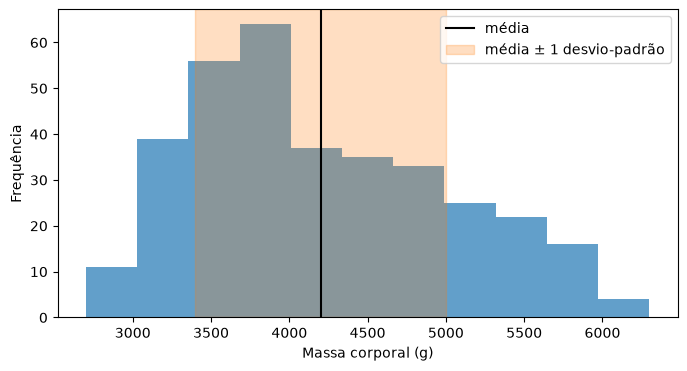

In [31]:
# Calcula a média e o desvio-padrão das massas
media_massa = massa_observada.mean()
desvio_massa = massa_observada.std(ddof=1)

# Destaca a faixa de um desvio-padrão ao redor da média
fig, eixo = plt.subplots(figsize=(8, 4))
eixo.hist(massa_observada, bins="fd", color="tab:blue", alpha=0.7)
eixo.axvline(media_massa, color="black", label="média")
eixo.axvspan(
    media_massa - desvio_massa,
    media_massa + desvio_massa,
    color="tab:orange",
    alpha=0.25,
    label="média ± 1 desvio-padrão",
)
eixo.set_xlabel("Massa corporal (g)")
eixo.set_ylabel("Frequência")
eixo.legend()
plt.show()

### 4.8 Intervalo interquartil

#### Fundamentação

O intervalo interquartil mede a extensão ocupada pelos $50\%$ centrais da
amostra ordenada (MORETTIN; BUSSAB, 2010, pp. 58–63; PINHEIRO et al., 2009,
pp. 38–41):

$$
\operatorname{IQR}=Q_3-Q_1=q_{0{,}75}-q_{0{,}25}.
\tag{7.10}
$$

Como depende de quantis e não dos extremos, $\operatorname{IQR}$ é mais
robusto a valores discrepantes que a amplitude total e o desvio-padrão
(PINHEIRO et al., 2009, pp. 41–42). Sua unidade é a mesma da variável.

#### Implementação manual

In [32]:
# Implementa o intervalo interquartil pela diferença entre Q3 e Q1.
def iqr(valores: pd.Series) -> float:
    """Calcula Q3 - Q1 por interpolação linear."""
    q1 = quantil(valores, 0.25)
    q3 = quantil(valores, 0.75)
    return q3 - q1

#### Implementação com biblioteca

SciPy oferece `stats.iqr` com interpolação linear.

In [33]:
# Implementa o intervalo interquartil com SciPy.
def iqr_scipy(valores: pd.Series) -> float:
    """Calcula o IQR com scipy.stats.iqr."""
    serie = _validos(valores)
    return float(stats.iqr(serie, interpolation="linear"))

#### Aplicação

Cálculo manual:

$$
\operatorname{IQR}=4750-3550=1200\ \mathrm{g}.
$$

In [34]:
# Compara o intervalo interquartil entre as duas implementações.
print("Manual:", iqr(massa))
print("SciPy:", iqr_scipy(massa))

Manual: 1200.0
SciPy: 1200.0


#### Visualização

A caixa representa o intervalo entre $Q_1$ e $Q_3$.

/var/folders/p_/hql2gkcd2rjfs0q18lzg_hy00000gn/T/ipykernel_24651/673315108.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixo.boxplot(massa_observada, vert=False)


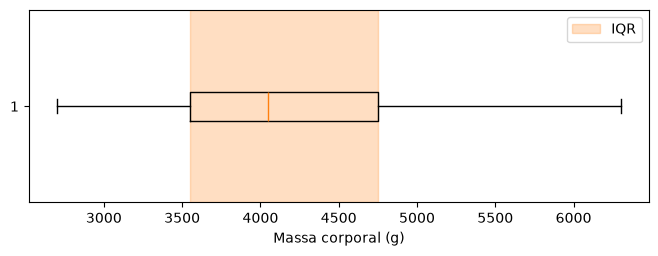

In [35]:
# Calcula o primeiro e o terceiro quartis
q1 = quantil(massa, 0.25)
q3 = quantil(massa, 0.75)

# Destaca o intervalo interquartil no boxplot
fig, eixo = plt.subplots(figsize=(8, 2.5))
eixo.boxplot(massa_observada, vert=False)
eixo.axvspan(q1, q3, color="tab:orange", alpha=0.25, label="IQR")
eixo.set_xlabel("Massa corporal (g)")
eixo.legend()
plt.show()

### 4.9 Coeficiente de variação

#### Fundamentação

O coeficiente de variação compara o desvio-padrão com a magnitude da média e,
portanto, expressa dispersão relativa (PINHEIRO et al., 2009, pp. 37–40;
BARBETTA; REIS; BORNIA, 2010, p. 76). A razão e sua forma percentual são:

$$
\operatorname{CV}=\frac{s}{\bar{x}},
\qquad
\operatorname{CV}_{\%}=100\frac{s}{\bar{x}}.
\tag{7.11}
$$

Onde:

- $\operatorname{CV}$: coeficiente de variação em forma decimal;
- $\operatorname{CV}_{\%}$: coeficiente de variação percentual.

Ambas as formas são adimensionais. As funções `cv` e `cv_scipy` devolvem a
forma percentual. A interpretação só é adequada para grandezas em escala de
razão, com zero significativo e média positiva suficientemente afastada de
zero; os grupos comparados também devem representar a mesma grandeza.

#### Implementação manual

In [36]:
# Implementa o coeficiente de variação amostral percentual.
def cv(valores: pd.Series) -> float:
    """Calcula o CV amostral percentual pela definição."""
    media_valor = media(valores)
    if abs(media_valor) < 1e-12:
        raise ValueError("O CV não é definido para média próxima de zero.")
    desvio_valor = desvio(valores)
    return 100 * desvio_valor / media_valor

#### Implementação com biblioteca

SciPy oferece stats.variation, que devolve $s/\bar{x}$. Seu padrão é
ddof=0; portanto, ddof=1 precisa ser declarado para reproduzir a convenção
amostral da disciplina.

In [37]:
# Implementa o coeficiente de variação com SciPy e ddof igual a 1.
def cv_scipy(valores: pd.Series) -> float:
    """Calcula o CV percentual com scipy.stats.variation e ddof=1."""
    serie = _validos(valores, minimo=2)
    if np.isclose(serie.mean(), 0):
        raise ValueError("O CV não é definido para média próxima de zero.")
    return float(100 * stats.variation(serie, ddof=1))

#### Aplicação

Cálculo manual:

$$
\operatorname{CV}_{\%}
=100\frac{801{,}95}{4201{,}75}
\approx19{,}09\%.
$$

In [38]:
# Compara o coeficiente de variação entre as duas implementações.
print("Manual:", cv(massa))
print("SciPy:", cv_scipy(massa))

Manual: 19.086183104297064
SciPy: 19.08618310429705


## 5. Medidas para dados agrupados em classes

### 5.1 Ponto médio de classe

#### Fundamentação

Para uma classe $j$, com limite inferior $L_j$ e limite superior $U_j$, o ponto
médio é (MORETTIN; BUSSAB, 2010, pp. 53–54):

$$
m_j=\frac{L_j+U_j}{2}.
\tag{7.12}
$$

Ao trabalhar com dados agrupados, cada observação da classe é representada por
$m_j$. Essa substituição é a origem da perda de informação e obriga o uso de
$\approx$ nas medidas reconstruídas a partir das classes.

#### Implementação manual

In [39]:
# Calcula manualmente os pontos médios das classes.
def pontos_medios(
    inferiores: np.ndarray,
    superiores: np.ndarray,
) -> list[float]:
    """Calcula um ponto médio para cada par de limites."""
    pontos = []
    for inferior, superior in zip(inferiores, superiores):
        pontos.append((inferior + superior) / 2)
    return pontos

#### Implementação com biblioteca

In [40]:
# Calcula os pontos médios das classes com NumPy.
def pontos_medios_np(
    inferiores: np.ndarray,
    superiores: np.ndarray,
) -> np.ndarray:
    """Calcula os pontos médios com vetores NumPy."""
    return (inferiores + superiores) / 2

#### Aplicação

As classes são definidas pelo critério de Freedman–Diaconis, estudado como
referência computacional na aula anterior.

Cálculo manual dos três primeiros pontos médios:

$$
\begin{aligned}
m_1&=\frac{2700+3027{,}27}{2}=2863{,}64\ \mathrm{g},\\
m_2&=\frac{3027{,}27+3354{,}55}{2}=3190{,}91\ \mathrm{g},\\
m_3&=\frac{3354{,}55+3681{,}82}{2}=3518{,}18\ \mathrm{g}.
\end{aligned}
$$

In [41]:
# Define as classes e calcula suas frequências
bordas_fd = np.histogram_bin_edges(massa_observada, bins="fd")
classes_fd = pd.cut(massa_observada, bins=bordas_fd, include_lowest=True)
frequencias_fd = classes_fd.value_counts(sort=False)

# Separa os limites inferiores e superiores
inferiores_fd = bordas_fd[:-1]
superiores_fd = bordas_fd[1:]

# Calcula os pontos médios pelas duas implementações
pontos_m = pontos_medios(
    inferiores_fd,
    superiores_fd,
)
pontos_np = pontos_medios_np(
    inferiores_fd,
    superiores_fd,
)

# Exibe e compara os primeiros pontos médios
print("Primeiros pontos manuais:", pontos_m[:3])
print("Primeiros pontos NumPy:", pontos_np[:3])

Primeiros pontos manuais: [np.float64(2863.6363636363635), np.float64(3190.909090909091), np.float64(3518.181818181818)]
Primeiros pontos NumPy: [2863.63636364 3190.90909091 3518.18181818]


#### Visualização

Os marcadores mostram os pontos médios que representam cada classe.

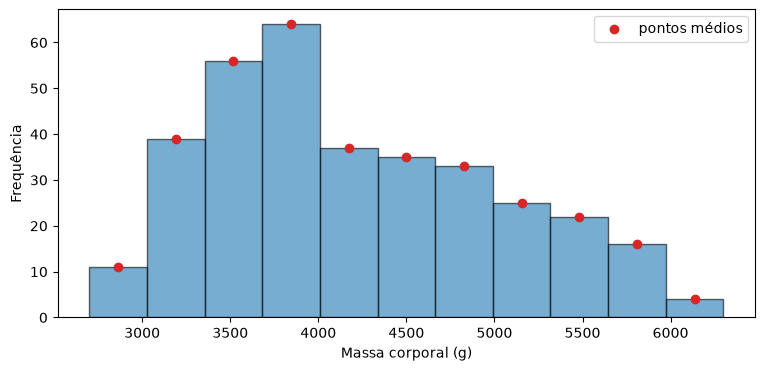

In [42]:
# Obtém larguras, frequências e pontos médios das classes
larguras_fd = superiores_fd - inferiores_fd
freq_visual = frequencias_fd.to_numpy()

# Representa as classes e seus pontos médios
fig, eixo = plt.subplots(figsize=(9, 4))
eixo.bar(
    pontos_np,
    freq_visual,
    width=larguras_fd,
    color="tab:blue",
    alpha=0.6,
    edgecolor="black",
)
eixo.scatter(pontos_np, freq_visual, color="tab:red", label="pontos médios")
eixo.set_xlabel("Massa corporal (g)")
eixo.set_ylabel("Frequência")
eixo.legend()
plt.show()

### 5.2 Média aproximada

#### Fundamentação

Ao representar os valores de cada classe por seu ponto médio, a média agrupada
é uma média ponderada pelas frequências (MORETTIN; BUSSAB, 2010, pp. 53–54):

$$
\bar{x}_g\approx
\frac{\sum_{j=1}^{k}f_jm_j}{\sum_{j=1}^{k}f_j}
=\frac{\sum_{j=1}^{k}f_jm_j}{n}.
\tag{7.13}
$$

Onde:

- $\bar{x}_g$: média aproximada dos dados agrupados;
- $k$: número de classes;
- $f_j$: frequência da classe $j$;
- $m_j$: ponto médio da classe $j$;
- $n=\sum_{j=1}^{k}f_j$: número total de observações.

O símbolo $\approx$ é obrigatório porque os valores individuais foram
substituídos pelos pontos médios.

#### Implementação manual

As funções agrupadas recebem os pontos médios calculados na seção anterior e
suas frequências.

In [43]:
# Implementa manualmente a média aproximada dos dados agrupados.
def media_g(
    pontos: list[float],
    freq: np.ndarray,
) -> float:
    """Calcula a média aproximada ponderada pelos pontos médios."""
    n = sum(freq)
    numerador = 0.0
    for ponto, frequencia in zip(pontos, freq):
        numerador += ponto * frequencia
    return numerador / n

#### Implementação com biblioteca

In [44]:
# Implementa a média agrupada ponderada com NumPy.
def media_g_np(
    pontos: np.ndarray,
    freq: np.ndarray,
) -> float:
    """Calcula a média agrupada com numpy.average."""
    return float(np.average(pontos, weights=freq))

#### Aplicação

Cálculo manual com os produtos $f_jm_j$ consolidados:

$$
\bar{x}_g
\approx\frac{1437218{,}18}{342}
\approx4202{,}39\ \mathrm{g}.
$$

In [45]:
# Converte as frequências para um vetor NumPy
freq_fd = frequencias_fd.to_numpy()

# Compara as médias agrupada e individual
print("Manual:", media_g(pontos_m, freq_fd))
print("NumPy:", media_g_np(pontos_np, freq_fd))
print("Média dos dados individuais:", massa_observada.mean())

Manual: 4202.392344497609
NumPy: 4202.392344497608
Média dos dados individuais: 4201.754385964912


### 5.3 Variância amostral aproximada

#### Fundamentação

Com a mesma representação por pontos médios, os desvios de cada classe são
ponderados por suas frequências. Mantendo a convenção amostral com denominador
$n-1$ (MORETTIN; BUSSAB, 2010, pp. 56–57; BARBETTA; REIS; BORNIA, 2010,
pp. 72–76):

$$
s_g^2\approx
\frac{\sum_{j=1}^{k}f_j(m_j-\bar{x}_g)^2}{n-1}.
\tag{7.14}
$$

Onde:

- $s_g^2$: variância amostral aproximada dos dados agrupados;
- $\bar{x}_g$: média aproximada definida em (7.13).

Essa variância não recupera, em geral, a dispersão dos dados individuais.

#### Implementação manual

In [46]:
# Implementa manualmente a variância amostral agrupada.
def variancia_g(
    pontos: list[float],
    freq: np.ndarray,
) -> float:
    """Calcula a variância amostral aproximada dos dados agrupados."""
    n = sum(freq)
    if n < 2:
        raise ValueError("A variância amostral exige n maior que 1.")

    media = media_g(pontos, freq)
    soma_quadrados = 0.0
    for ponto, frequencia in zip(pontos, freq):
        soma_quadrados += frequencia * (ponto - media) ** 2
    return soma_quadrados / (n - 1)

#### Implementação com biblioteca

In [47]:
# Implementa a variância amostral agrupada com NumPy.
def variancia_g_np(
    pontos: np.ndarray,
    freq: np.ndarray,
) -> float:
    """Calcula a variância agrupada com operações NumPy."""
    n = freq.sum()
    if n < 2:
        raise ValueError("A variância amostral exige n maior que 1.")
    media = np.average(pontos, weights=freq)
    soma_quadrados = np.sum(freq * (pontos - media) ** 2)
    return float(soma_quadrados / (n - 1))

#### Aplicação

Cálculo manual com os desvios quadráticos ponderados consolidados:

$$
s_g^2
\approx\frac{224945976{,}51}{342-1}
\approx659665{,}62\ \mathrm{g}^2.
$$

In [48]:
# Compara as variâncias dos dados agrupados e individuais.
print("Manual:", variancia_g(pontos_m, freq_fd))
print("NumPy:", variancia_g_np(pontos_np, freq_fd))
print("Variância dos dados individuais:", massa_observada.var(ddof=1))

Manual: 659665.6202684068
NumPy: 659665.6202684068
Variância dos dados individuais: 643131.0773267479


### 5.4 Desvio-padrão amostral aproximado

#### Fundamentação

O desvio-padrão agrupado é a raiz quadrada positiva da variância agrupada
aproximada, seguindo a relação entre variância e desvio-padrão (MORETTIN;
BUSSAB, 2010, pp. 56–57; BARBETTA; REIS; BORNIA, 2010, pp. 72–76):

$$
s_g\approx\sqrt{s_g^2}.
\tag{7.15}
$$

Onde:

- $s_g$: desvio-padrão amostral aproximado dos dados agrupados;
- $s_g^2$: variância definida em (7.14).

O símbolo $\approx$ recorda que essas medidas dependem dos pontos médios.

#### Implementação manual

In [49]:
# Implementa o desvio-padrão aproximado dos dados agrupados.
def desvio_g(
    pontos: list[float],
    freq: np.ndarray,
) -> float:
    """Calcula a raiz da variância amostral agrupada."""
    return variancia_g(pontos, freq) ** 0.5

#### Implementação com biblioteca

In [50]:
# Implementa o desvio-padrão agrupado com NumPy.
def desvio_g_np(
    pontos: np.ndarray,
    freq: np.ndarray,
) -> float:
    """Calcula o desvio-padrão agrupado com numpy.sqrt."""
    return float(np.sqrt(variancia_g_np(pontos, freq)))

#### Aplicação

Cálculo manual:

$$
s_g\approx\sqrt{659665{,}62}\approx812{,}20\ \mathrm{g}.
$$

In [51]:
# Compara os desvios-padrão dos dados agrupados e individuais.
print("Manual:", desvio_g(pontos_m, freq_fd))
print("NumPy:", desvio_g_np(pontos_np, freq_fd))
print("Desvio-padrão dos dados individuais:", massa_observada.std(ddof=1))

Manual: 812.1980178924391
NumPy: 812.1980178924391
Desvio-padrão dos dados individuais: 801.9545356980955


### 5.5 Classe mediana

#### Fundamentação

A localização da mediana em dados agrupados começa pela frequência acumulada.
A classe mediana é a primeira que alcança a posição central da distribuição
(MORETTIN; BUSSAB, 2010, pp. 60–61):

$$
F_j=\sum_{r=1}^{j}f_r,
\qquad
j_{\mathrm{med}}=\min\left\{j:F_j\geq\frac{n}{2}\right\}.
\tag{7.16}
$$

Onde:

- $r$: índice usado na soma;
- $j_{\mathrm{med}}$: índice da primeira classe que alcança $n/2$.

A regra identifica uma classe, não recupera a mediana exata. Se $F_j=n/2$
coincidir com uma fronteira, a localização depende da convenção dos
intervalos; com os intervalos à direita usados por `pd.cut`, a fronteira
pertence à classe $j$.

#### Implementação manual

O índice Python começa em zero. Portanto, o retorno 0 representa a primeira
classe.

In [52]:
# Localiza manualmente a primeira classe que alcança a posição mediana.
def idx_classe_mediana(freq: np.ndarray) -> int:
    """Retorna o índice zero-based da primeira classe com F_j >= n/2."""
    alvo = sum(freq) / 2
    acumulada = 0
    for indice, frequencia in enumerate(freq):
        acumulada += frequencia
        if acumulada >= alvo:
            return indice
    raise RuntimeError("Não foi possível localizar a classe mediana.")

#### Implementação com biblioteca

In [53]:
# Localiza a classe mediana com a frequência acumulada do NumPy.
def idx_classe_mediana_np(freq: np.ndarray) -> int:
    """Localiza a classe mediana com cumsum e searchsorted."""
    acumuladas = np.cumsum(freq)
    return int(np.searchsorted(acumuladas, freq.sum() / 2, side="left"))

#### Aplicação

Cálculo manual:

$$
\frac{n}{2}=171,
\qquad
F_4=170<171\leq F_5=207
\quad\Longrightarrow\quad
j_{\mathrm{med}}=5.
$$

Logo, o índice Python da classe mediana é $4$.

In [54]:
# Localiza a classe mediana pelas duas implementações
idx_m = idx_classe_mediana(freq_fd)
idx_np = idx_classe_mediana_np(freq_fd)

# Exibe e compara a classe mediana
print("Índice manual:", idx_m)
print("Índice NumPy:", idx_np)
print("Classe mediana:", frequencias_fd.index[idx_np])

Índice manual: 4
Índice NumPy: 4
Classe mediana: (4009.091, 4336.364]


#### Visualização

A primeira barra acumulada que alcança $n/2$ identifica a classe mediana.

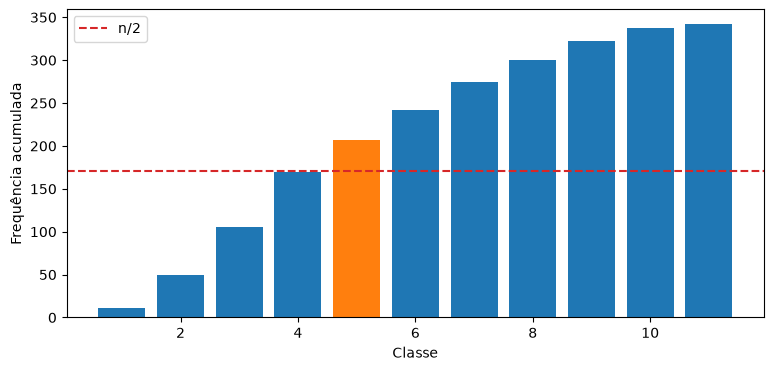

In [55]:
# Calcula as frequências acumuladas por classe
acumuladas = np.cumsum(freq_fd)
posicoes = np.arange(1, len(freq_fd) + 1)

# Destaca a primeira classe que alcança a mediana
fig, eixo = plt.subplots(figsize=(9, 4))
eixo.bar(posicoes, acumuladas, color="tab:blue")
eixo.axhline(freq_fd.sum() / 2, color="tab:red", linestyle="--", label="n/2")
eixo.bar(posicoes[idx_np], acumuladas[idx_np], color="tab:orange")
eixo.set_xlabel("Classe")
eixo.set_ylabel("Frequência acumulada")
eixo.legend()
plt.show()

### 5.6 Classes modais

#### Fundamentação

A moda depende apenas das frequências observadas; em dados agrupados, são
modais todas as classes que atingem a maior frequência (MORETTIN; BUSSAB,
2010, pp. 52–54):

$$
\mathcal{C}_{\mathrm{modal}}
=\left\{j:f_j=\max_{1\leq r\leq k}f_r\right\}.
\tag{7.17}
$$

Onde:

- $r$: índice de classe usado na maximização;
- $\mathcal{C}_{\mathrm{modal}}$: conjunto dos índices das classes modais.

Retornar todas as classes evita ocultar empates. Uma classe modal não é a moda
exata dos valores originais.

#### Implementação manual

In [56]:
# Identifica manualmente todas as classes de frequência máxima.
def idx_classes_modais(freq: np.ndarray) -> list[int]:
    """Retorna todos os índices zero-based com frequência máxima."""
    maior = max(freq)
    indices = []
    for indice, frequencia in enumerate(freq):
        if frequencia == maior:
            indices.append(indice)
    return indices

#### Implementação com biblioteca

In [57]:
# Identifica as classes modais com NumPy.
def idx_classes_modais_np(freq: np.ndarray) -> list[int]:
    """Retorna todos os índices modais com NumPy."""
    return np.flatnonzero(freq == freq.max()).tolist()

#### Aplicação

Cálculo manual:

$$
\max_j f_j=64=f_4
\quad\Longrightarrow\quad
\mathcal{C}_{\mathrm{modal}}=\{4\}.
$$

Logo, o índice Python da classe modal é $3$.

In [58]:
# Localiza as classes modais pelas duas implementações
idx_m = idx_classes_modais(freq_fd)
idx_np = idx_classes_modais_np(freq_fd)

# Exibe e compara as classes modais
print("Índices manuais:", idx_m)
print("Índices NumPy:", idx_np)
print("Classes modais:", [frequencias_fd.index[i] for i in idx_np])

Índices manuais: [3]
Índices NumPy: [3]
Classes modais: [Interval(3681.818, 4009.091, closed='right')]


#### Visualização

As barras destacadas representam as classes modais.

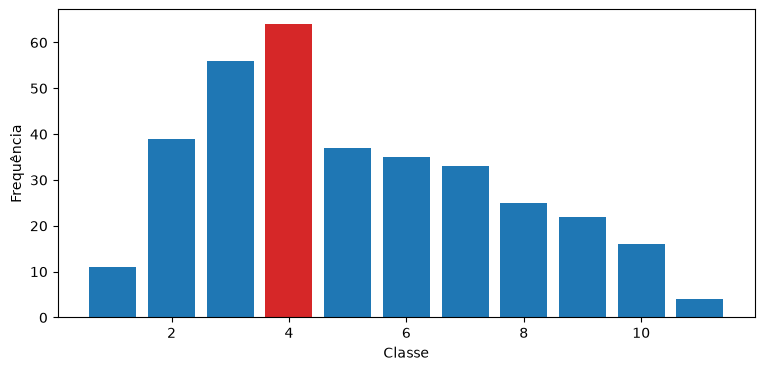

In [59]:
# Define posições e cores das classes
posicoes = np.arange(1, len(freq_fd) + 1)
cores = [
    "tab:red" if indice in idx_np else "tab:blue"
    for indice in range(len(freq_fd))
]

# Destaca graficamente as classes modais
fig, eixo = plt.subplots(figsize=(9, 4))
eixo.bar(posicoes, freq_fd, color=cores)
eixo.set_xlabel("Classe")
eixo.set_ylabel("Frequência")
plt.show()

## 6. Comparação entre dados não agrupados e agrupados em classes

### 6.1 Conferência das medidas para dados não agrupados

In [60]:
# Constrói o resumo das medidas não agrupadas
resumo = pd.DataFrame({
    "manual": {
        "média (g)": media(massa),
        "mediana (g)": mediana(massa),
        "Q1 (g)": quantil(massa, 0.25),
        "Q2 (g)": quantil(massa, 0.50),
        "Q3 (g)": quantil(massa, 0.75),
        "amplitude (g)": amplitude(massa),
        "variância amostral (g²)": variancia(massa),
        "desvio-padrão amostral (g)": desvio(massa),
        "IQR (g)": iqr(massa),
        "CV (%)": cv(massa),
    },
    "bibliotecas": {
        "média (g)": media_pd(massa),
        "mediana (g)": mediana_pd(massa),
        "Q1 (g)": quantil_np(massa, 0.25),
        "Q2 (g)": quantil_np(massa, 0.50),
        "Q3 (g)": quantil_np(massa, 0.75),
        "amplitude (g)": amplitude_pd(massa),
        "variância amostral (g²)": variancia_pd(massa),
        "desvio-padrão amostral (g)": desvio_pd(massa),
        "IQR (g)": iqr_scipy(massa),
        "CV (%)": cv_scipy(massa),
    },
})

# Calcula a diferença entre as implementações
resumo["diferença"] = resumo["manual"] - resumo["bibliotecas"]

# Exibe o resumo com arredondamento
resumo.round(10)

,manual,bibliotecas,diferença
média (g),4201.754386,4201.754386,0.000000e+00
mediana (g),4050.000000,4050.000000,0.000000e+00
Q1 (g),3550.000000,3550.000000,0.000000e+00
Q2 (g),4050.000000,4050.000000,0.000000e+00
Q3 (g),4750.000000,4750.000000,0.000000e+00
amplitude (g),3600.000000,3600.000000,0.000000e+00
variância amostral (g²),643131.077327,643131.077327,5.000000e-10
desvio-padrão amostral (g),801.954536,801.954536,0.000000e+00
IQR (g),1200.000000,1200.000000,0.000000e+00
CV (%),19.086183,19.086183,0.000000e+00


As diferenças devem ser nulas ou compatíveis com arredondamento de ponto
flutuante.

### 6.2 Comparação entre espécies

Para cada espécie, aplique as funções às massas observadas. O groupby organiza
os grupos; cada medida continua sendo calculada pelas funções documentadas.

In [61]:
# Calcula as medidas de cada espécie
linhas = []
for especie, grupo in penguins.groupby("species", observed=True):
    valores = grupo["body_mass_g"]
    linhas.append({
        "species": especie,
        "n": int(valores.count()),
        "media": media_pd(valores),
        "mediana": mediana_pd(valores),
        "desvio_padrao": desvio_pd(valores),
        "cv_pct": cv_scipy(valores),
    })

# Organiza e exibe os resultados por espécie
por_especie = pd.DataFrame(linhas).set_index("species")
por_especie.round(2)

,n,media,mediana,desvio_padrao,cv_pct
species,,,,,
Adelie,151,3700.66,3700.0,458.57,12.39
Chinstrap,68,3733.09,3700.0,384.34,10.30
Gentoo,123,5076.02,5000.0,504.12,9.93


Interpretação esperada:

- Gentoo apresenta a maior massa média;
- Adelie apresenta o maior coeficiente de variação;
- maior posição e maior variabilidade relativa não são a mesma afirmação.

### 6.3 Comparação entre dados não agrupados e agrupados em classes

In [62]:
# Constrói a comparação entre dados individuais e agrupados
comparacao = pd.DataFrame({
    "dados_individuais": [
        media_pd(massa),
        variancia_pd(massa),
        desvio_pd(massa),
    ],
    "dados_agrupados": [
        media_g_np(pontos_np, freq_fd),
        variancia_g_np(pontos_np, freq_fd),
        desvio_g_np(pontos_np, freq_fd),
    ],
}, index=[
    "média (g)",
    "variância amostral (g²)",
    "desvio-padrão amostral (g)",
])

# Calcula a perda introduzida pelo agrupamento
comparacao["diferença"] = (
    comparacao["dados_agrupados"] - comparacao["dados_individuais"]
)

# Exibe a comparação com arredondamento
comparacao.round(2)

,dados_individuais,dados_agrupados,diferença
média (g),4201.75,4202.39,0.64
variância amostral (g²),643131.08,659665.62,16534.54
desvio-padrão amostral (g),801.95,812.20,10.24


A proximidade dos resultados neste conjunto não elimina a perda de informação:
outros dados individuais compatíveis com as mesmas frequências de classe
produziriam as mesmas aproximações agrupadas.

## 7. Estudo e exercícios

### 7.1 Materiais didáticos

- [Banco de questões e provas 2026.2](../apostila/banco_questoes_provas_2026_2.pdf): seções 2.1–2.3, páginas 34–83, para medidas de posição, dispersão e separatrizes.
- MORETTIN; BUSSAB (2010), capítulo 3, páginas PDF 52–63: medidas de posição, dispersão, quantis e dados agrupados.
- PINHEIRO et al. (2009), seções 1.5–1.7, páginas PDF 35–42: centralidade, dispersão, coeficiente de variação, intervalo interquartil e robustez a valores extremos.
- BARBETTA; REIS; BORNIA (2010), capítulo 3, seção 3.4, páginas PDF 69–82: amplitude, variância, desvio-padrão, coeficiente de variação e quartis.
- [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/): fonte e documentação das variáveis utilizadas nas aplicações.
- [Documentação do pandas](https://pandas.pydata.org/docs/), [NumPy](https://numpy.org/doc/) e [SciPy](https://docs.scipy.org/doc/scipy/): funções utilizadas nos cálculos e nas conferências.

### 7.2 Exercícios indicados

- [Banco de questões e provas 2026.2](../apostila/banco_questoes_provas_2026_2.pdf), questão 56, página 26: quartis, intervalo interquartil e identificação de valores discrepantes.
- [Banco de questões e provas 2026.2](../apostila/banco_questoes_provas_2026_2.pdf), questão 113, página 52: média, moda, mediana, variância e desvio-padrão.
- [Banco de questões e provas 2026.2](../apostila/banco_questoes_provas_2026_2.pdf), questão 122, página 54: média, variância, desvio-padrão e diagrama de caixa.
- [Banco de questões e provas 2026.2](../apostila/banco_questoes_provas_2026_2.pdf), questão 123, página 54: interpretação da variância, do desvio-padrão e do coeficiente de variação.

## 8. Referências

- BARBETTA, Pedro Alberto; REIS, Marcelo Menezes; BORNIA, Antonio Cezar. *Estatística para cursos de engenharia e informática*. 3. ed. São Paulo: Atlas, 2010.
- HORST, Allison Marie; HILL, Alison Presmanes; GORMAN, Kristen B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. Versão 0.1.0. Zenodo, 2020. DOI: [10.5281/zenodo.3960218](https://doi.org/10.5281/zenodo.3960218).
- MCKINNEY, Wes. *Python for Data Analysis: Data Wrangling with pandas, NumPy, and IPython*. 2. ed. Sebastopol: O'Reilly Media, 2017.
- MORETTIN, Pedro A.; BUSSAB, Wilton O. *Estatística básica*. 6. ed. São Paulo: Saraiva, 2010.
- PINHEIRO, João Ismael D. et al. *Estatística básica: a arte de trabalhar com dados*. Rio de Janeiro: Elsevier, 2009.